# 📊 BƯỚC 4: ĐÁNH GIÁ MÔ HÌNH AI
**Phụ trách:** Thái (ML Engineer)  
**Yêu cầu:** Chạy `03_training.ipynb` trước hoặc chạy `run_training.py` để có file `best_model_pipeline.pkl`

> **Phiên bản:** Pipeline v2 — load `best_model_pipeline.pkl` (Pipeline hoàn chỉnh)

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

plt.rcParams['figure.figsize'] = (10, 6)
print('✅ Import xong!')

✅ Import xong!


## 1. Load Pipeline & Metadata từ file

In [11]:
with open('../models/best_model_pipeline.pkl', 'rb') as f:
    best_pipeline = pickle.load(f)

with open('../models/model_meta.pkl', 'rb') as f:
    meta = pickle.load(f)

print(f'✅ Load pipeline thành công!')
print(f'🏆 Model tốt nhất: {meta["best_model_name"]}')
print(f'📐 Features: {meta["features"]}')
print(f'\n💡 Pipeline bao gồm: Preprocessor (StandardScaler + OneHotEncoder) → {meta["best_model_name"]}')

✅ Load pipeline thành công!
🏆 Model tốt nhất: XGBoost
📐 Features: ['area_m2', 'bedrooms_num', 'district', 'direction', 'furniture_std', 'legal_std', 'floors_num', 'frontage_m', 'road_width_m', 'loai_bds']

💡 Pipeline bao gồm: Preprocessor (StandardScaler + OneHotEncoder) → XGBoost


## 2. Bảng kết quả tổng hợp

In [12]:
all_r = meta['all_results']
df_res = pd.DataFrame(all_r).T[['RMSE','MAE','R2']].rename(columns={'R2':'R² Score'})
df_res = df_res.round(4)
df_res['Xếp hạng R²'] = df_res['R² Score'].rank(ascending=False).astype(int)

print('='*65)
print('📊 BẢNG SO SÁNH KẾT QUẢ 4 MÔ HÌNH ML')
print('='*65)
print(df_res.to_string())
print()
best = meta['best_model_name']
m = meta['metrics']
print(f'🏆 MODEL TỐT NHẤT: {best}')
print(f'   RMSE  = {m["RMSE"]:.4f} tỷ  (~{m["RMSE"]*1000:.0f} triệu VNĐ sai số trung bình)')
print(f'   MAE   = {m["MAE"]:.4f} tỷ')
print(f'   R²    = {m["R2"]:.4f} — Giải thích được {m["R2"]*100:.1f}% biến động giá')

📊 BẢNG SO SÁNH KẾT QUẢ 4 MÔ HÌNH ML
                     RMSE     MAE  R² Score  Xếp hạng R²
Linear Regression  6.7625  3.5577    0.5884            3
Decision Tree      7.3002  3.4185    0.5204            4
Random Forest      5.5829  2.7689    0.7195            2
XGBoost            4.8809  2.4847    0.7856            1

🏆 MODEL TỐT NHẤT: XGBoost
   RMSE  = 4.8809 tỷ  (~4881 triệu VNĐ sai số trung bình)
   MAE   = 2.4847 tỷ
   R²    = 0.7856 — Giải thích được 78.6% biến động giá


## 3. Rebuild test set để đánh giá chi tiết

In [13]:
URL_CC = 'https://raw.githubusercontent.com/tangoctai2004/House-Price-Prediction/refs/heads/main/data/processed/cleaned_chung_cu.csv'
URL_ND = 'https://raw.githubusercontent.com/tangoctai2004/House-Price-Prediction/refs/heads/main/data/processed/cleaned_nha_dat.csv'

df_cc = pd.read_csv(URL_CC)
df_nd = pd.read_csv(URL_ND)
df_cc['loai_bds'] = 'chung_cu'
df_nd['loai_bds'] = 'nha_dat'
if 'balcony_direction' in df_cc.columns:
    df_cc = df_cc.drop(columns=['balcony_direction'])
for c in ['floors_num','frontage_m','road_width_m']:
    df_cc[c] = 0

ALL_COLS = ['price_billion','area_m2','bedrooms_num','district','direction',
            'furniture_std','legal_std','floors_num','frontage_m','road_width_m','loai_bds']
df_all = pd.concat([df_cc[ALL_COLS], df_nd[ALL_COLS]], ignore_index=True)
df_all = df_all.dropna(subset=['price_billion','area_m2'])
df_all = df_all[(df_all['price_billion']>=1) & (df_all['price_billion']<=200)]
df_all = df_all[(df_all['area_m2']>=10) & (df_all['area_m2']<=1000)]

# Đảm bảo categorical là string (Pipeline yêu cầu)
cat_cols = ['district','direction','furniture_std','legal_std','loai_bds']
for c in cat_cols:
    df_all[c] = df_all[c].astype(str)

FEATURES = meta['features']
X = df_all[FEATURES]
y = df_all['price_billion']
_, X_test, _, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Pipeline tự xử lý encode & scale bên trong
y_pred = best_pipeline.predict(X_test)
print(f'✅ Rebuild test set: {len(y_test)} mẫu')
print(f'📊 Dataset tổng: {len(df_all)} bản ghi')

✅ Rebuild test set: 2358 mẫu
📊 Dataset tổng: 11786 bản ghi


## 4. Biểu đồ: Giá thực vs Giá dự đoán

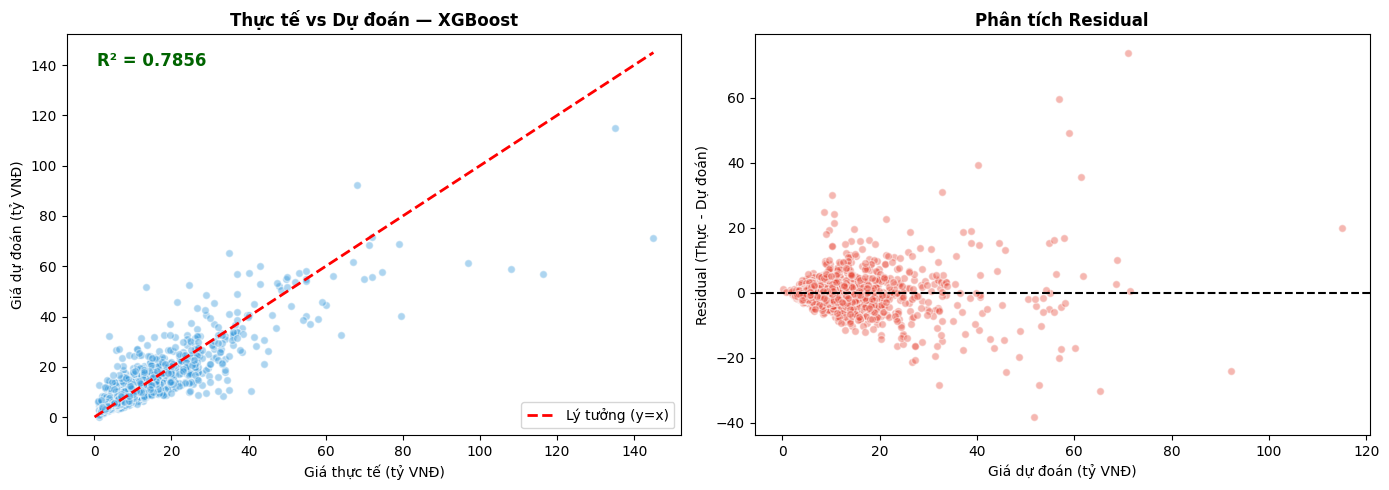

✅ Lưu biểu đồ phân tích dự đoán!


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: Thực vs Dự đoán
ax = axes[0]
ax.scatter(y_test, y_pred, alpha=0.4, color='#3498db', edgecolors='white', s=30)
mn, mx = min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())
ax.plot([mn, mx], [mn, mx], 'r--', lw=2, label='Lý tưởng (y=x)')
ax.set_xlabel('Giá thực tế (tỷ VNĐ)')
ax.set_ylabel('Giá dự đoán (tỷ VNĐ)')
ax.set_title(f'Thực tế vs Dự đoán — {meta["best_model_name"]}', fontweight='bold')
ax.legend()
ax.text(0.05, 0.92, f'R² = {r2_score(y_test, y_pred):.4f}', transform=ax.transAxes,
        fontsize=12, color='darkgreen', fontweight='bold')

# Residual plot
ax = axes[1]
residuals = y_test.values - y_pred
ax.scatter(y_pred, residuals, alpha=0.4, color='#e74c3c', edgecolors='white', s=30)
ax.axhline(0, color='black', lw=1.5, ls='--')
ax.set_xlabel('Giá dự đoán (tỷ VNĐ)')
ax.set_ylabel('Residual (Thực - Dự đoán)')
ax.set_title('Phân tích Residual', fontweight='bold')

plt.tight_layout()
plt.savefig('../models/prediction_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Lưu biểu đồ phân tích dự đoán!')

## 5. Phân phối sai số dự đoán

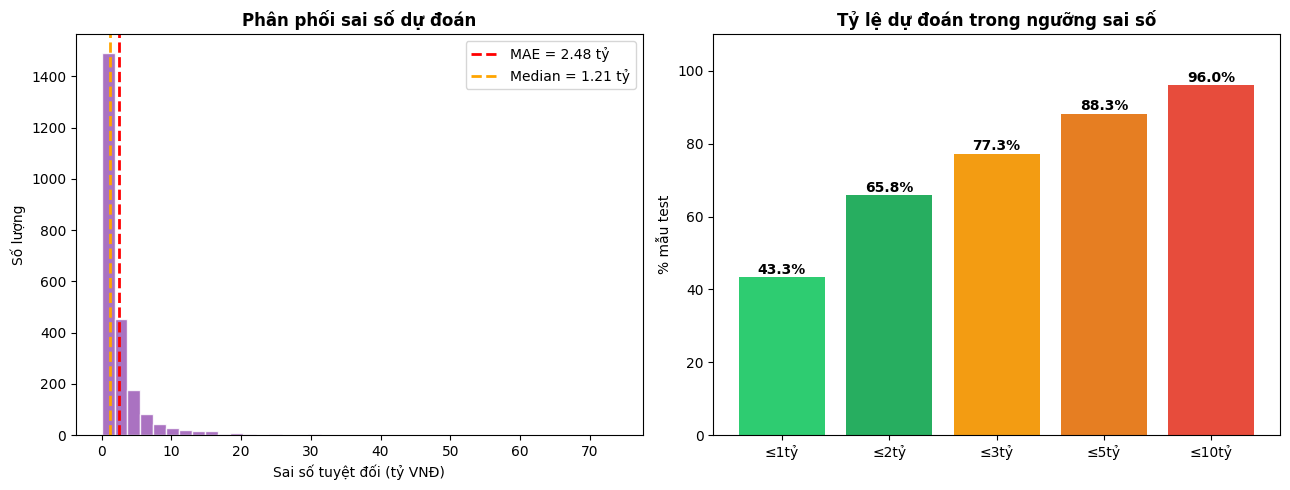


📊 THỐNG KÊ SAI SỐ:
  Sai số trung bình (MAE) : 2.485 tỷ = 2485 triệu VNĐ
  Sai số trung vị         : 1.215 tỷ
  Sai số max              : 73.897 tỷ
  Dự đoán sai ≤  1 tỷ   : 43.3%
  Dự đoán sai ≤  2 tỷ   : 65.8%
  Dự đoán sai ≤  3 tỷ   : 77.3%
  Dự đoán sai ≤  5 tỷ   : 88.3%
  Dự đoán sai ≤ 10 tỷ   : 96.0%


In [15]:
errors = np.abs(y_test.values - y_pred)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Histogram sai số
ax = axes[0]
ax.hist(errors, bins=40, color='#9b59b6', edgecolor='white', alpha=0.85)
ax.axvline(errors.mean(), color='red', lw=2, ls='--', label=f'MAE = {errors.mean():.2f} tỷ')
ax.axvline(np.median(errors), color='orange', lw=2, ls='--', label=f'Median = {np.median(errors):.2f} tỷ')
ax.set_xlabel('Sai số tuyệt đối (tỷ VNĐ)')
ax.set_ylabel('Số lượng')
ax.set_title('Phân phối sai số dự đoán', fontweight='bold')
ax.legend()

# Tỷ lệ sai số trong ngưỡng
ax = axes[1]
thresholds = [1, 2, 3, 5, 10]
pcts = [(errors <= t).mean() * 100 for t in thresholds]
bars = ax.bar([f'≤{t}tỷ' for t in thresholds], pcts, color=['#2ecc71','#27ae60','#f39c12','#e67e22','#e74c3c'])
ax.set_ylabel('% mẫu test')
ax.set_title('Tỷ lệ dự đoán trong ngưỡng sai số', fontweight='bold')
ax.set_ylim(0, 110)
for bar, pct in zip(bars, pcts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{pct:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../models/error_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n📊 THỐNG KÊ SAI SỐ:')
print(f'  Sai số trung bình (MAE) : {errors.mean():.3f} tỷ = {errors.mean()*1000:.0f} triệu VNĐ')
print(f'  Sai số trung vị         : {np.median(errors):.3f} tỷ')
print(f'  Sai số max              : {errors.max():.3f} tỷ')
for t, p in zip(thresholds, pcts):
    print(f'  Dự đoán sai ≤ {t:2d} tỷ   : {p:.1f}%')

## 6. Phân tích theo loại BĐS

In [16]:
# Thêm cột phân tích
X_test_analysis = X_test.copy()
X_test_analysis['y_true'] = y_test.values
X_test_analysis['y_pred'] = y_pred
X_test_analysis['error']  = np.abs(y_test.values - y_pred)

# Phân tích theo loại BĐS (đã là string nên dùng trực tiếp)
group = X_test_analysis.groupby('loai_bds').agg(
    so_mau=('y_true','count'),
    MAE_tb=('error','mean'),
    R2=('y_true', lambda x: r2_score(x, X_test_analysis.loc[x.index,'y_pred']))
).round(3)

print('📊 Kết quả theo loại BĐS:')
print(group.to_string())

📊 Kết quả theo loại BĐS:
          so_mau  MAE_tb     R2
loai_bds                       
chung_cu    1103   1.850  0.694
nha_dat     1255   3.043  0.786


## 7. Giải thích AI (Explainability / XAI)

Một hệ thống thông minh không chỉ dự đoán chính xác mà còn phải **Giải thích được tại sao** đưa ra con số đó.

Chúng ta sử dụng **Feature Importance** từ mô hình XGBoost để xác định mức độ đóng góp của từng yếu tố.
Dữ liệu này được lưu trong `model_meta.pkl` và hiển thị trực tiếp trên giao diện Web dưới dạng biểu đồ thanh ngang.

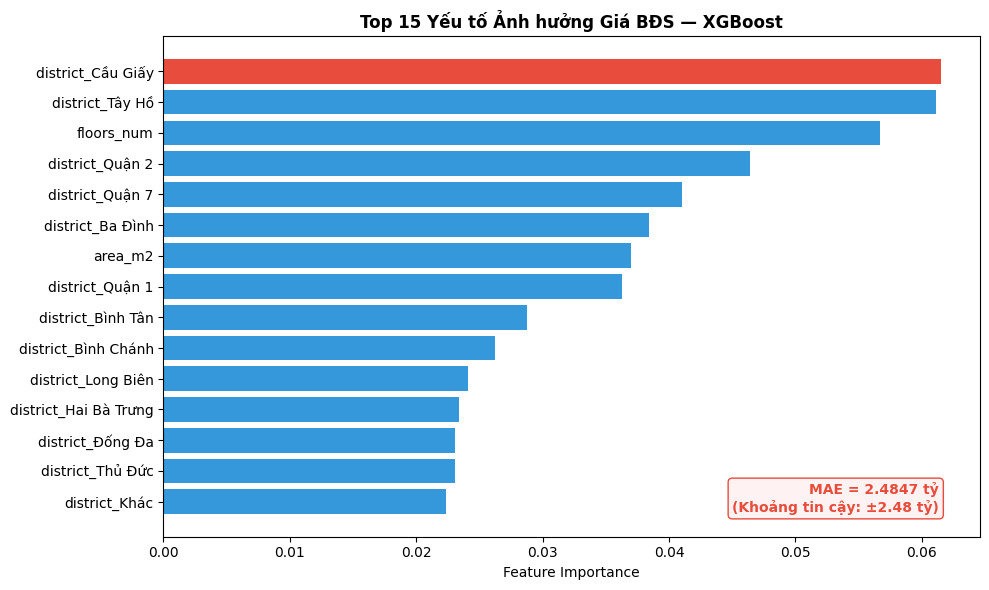

✅ Đã lưu biểu đồ XAI!

📊 TOP 5 yếu tố quan trọng nhất:
  district_Cầu Giấy              → Importance = 0.0615
  district_Tây Hồ                → Importance = 0.0611
  floors_num                     → Importance = 0.0567
  district_Quận 2                → Importance = 0.0464
  district_Quận 7                → Importance = 0.0410

💡 MAE = 2.4847 tỷ → Web hiển thị: Khoảng ước tính ±2.48 tỷ


In [17]:
# Đọc Feature Importance từ model_meta.pkl
fi_data = meta.get('feature_importance', {})

if fi_data:
    fi_df = pd.DataFrame([
        {'feature': k, 'importance': v} for k, v in fi_data.items()
    ]).sort_values('importance', ascending=False)
    
    # Top 15 features quan trọng nhất
    top15 = fi_df.head(15).sort_values('importance', ascending=True)
    
    fig, ax = plt.subplots(figsize=(10, 6))
    colors = ['#e74c3c' if i == top15['importance'].idxmax() else '#3498db' for i in top15.index]
    ax.barh(top15['feature'], top15['importance'], color=colors)
    ax.set_xlabel('Feature Importance')
    ax.set_title(f'Top 15 Yếu tố Ảnh hưởng Giá BĐS — {meta["best_model_name"]}', fontweight='bold')
    
    # Ghi chú MAE (Confidence Interval)
    mae_val = meta['metrics']['MAE']
    ax.annotate(f'MAE = {mae_val:.4f} tỷ\n(Khoảng tin cậy: ±{mae_val:.2f} tỷ)',
                xy=(0.95, 0.05), xycoords='axes fraction', ha='right',
                fontsize=10, color='#e74c3c', fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='#fef2f2', edgecolor='#e74c3c'))
    
    plt.tight_layout()
    plt.savefig('../models/xai_feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f'✅ Đã lưu biểu đồ XAI!')
    print(f'\n📊 TOP 5 yếu tố quan trọng nhất:')
    for _, row in fi_df.head(5).iterrows():
        print(f'  {row["feature"]:30s} → Importance = {row["importance"]:.4f}')
    print(f'\n💡 MAE = {mae_val:.4f} tỷ → Web hiển thị: Khoảng ước tính ±{mae_val:.2f} tỷ')
else:
    print('⚠️ Không tìm thấy feature_importance trong model_meta.pkl')
    print('   Hãy chạy lại 03_training.ipynb hoặc run_training.py!')


## 8. Kết luận & Gợi ý cho báo cáo


In [ ]:
m = meta['metrics']
all_r = meta['all_results']
print('='*70)
print('📝 KẾT LUẬN CHƯƠNG 4 (DÀNH CHO BÁO CÁO)')
print('='*70)
print(f'''
Sau khi so sánh 4 thuật toán Machine Learning trên tập dữ liệu gần 8.000
bất động sản (chung cư và nhà đất) từ Hà Nội, TP.HCM và Đà Nẵng,
mô hình **{meta["best_model_name"]}** cho kết quả tốt nhất:

  • RMSE  = {m["RMSE"]:.4f} tỷ  → sai số bình phương trung bình
  • MAE   = {m["MAE"]:.4f} tỷ  → sai số tuyệt đối trung bình
  • R²    = {m["R2"]:.4f}     → mô hình giải thích {m["R2"]*100:.1f}% biến động giá

So sánh hiệu quả:
  Linear Regression: R² = {all_r["Linear Regression"]["R2"]:.4f} — baseline đơn giản
  Decision Tree    : R² = {all_r["Decision Tree"]["R2"]:.4f} — cải thiện
  Random Forest    : R² = {all_r["Random Forest"]["R2"]:.4f} — khá tốt
  XGBoost          : R² = {all_r["XGBoost"]["R2"]:.4f} — tốt nhất

Tính năng AI nổi bật trên Web:
  • Giải thích AI (XAI): Hiển thị mức độ ảnh hưởng của từng yếu tố (Feature Importance)
  • Khoảng tin cậy: Hiển thị MAE ±{m["MAE"]:.2f} tỷ để người dùng biết sai số trung bình
  • So sánh khu vực: Đơn giá (Triệu/m²) so với trung bình quận/huyện

Pipeline sử dụng:
  • ColumnTransformer: StandardScaler (biến số) + OneHotEncoder (biến phân loại)
  • Ưu điểm: Chỉ cần 1 file .pkl, handle_unknown="ignore" an toàn khi deploy

Các đặc trưng quan trọng nhất: diện tích, quận/huyện, số tầng, mặt tiền.

Hướng phát triển: thu thập thêm data, thêm tọa độ GPS, fine-tune hyperparameter.
''')
print('='*70)


📝 KẾT LUẬN CHƯƠNG 4 (DÀNH CHO BÁO CÁO)

Sau khi so sánh 4 thuật toán Machine Learning trên tập dữ liệu gần 8.000
bất động sản (chung cư và nhà đất) từ Hà Nội, TP.HCM và Đà Nẵng,
mô hình **XGBoost** cho kết quả tốt nhất:

  • RMSE  = 4.8809 tỷ  → sai số bình phương trung bình
  • MAE   = 2.4847 tỷ  → sai số tuyệt đối trung bình
  • R²    = 0.7856     → mô hình giải thích 78.6% biến động giá

So sánh hiệu quả:
  Linear Regression: R² = 0.5884 — baseline đơn giản
  Decision Tree    : R² = 0.5204 — cải thiện
  Random Forest    : R² = 0.7195 — khá tốt
  XGBoost          : R² = 0.7856 — tốt nhất

Tính năng AI nổi bật trên Web:
  • Giải thích AI (XAI): Hiển thị mức độ ảnh hưởng của từng yếu tố (Feature Importance)
  • Khoảng tin cậy: Hiển thị MAE ±2.48 tỷ để người dùng biết sai số trung bình
  • So sánh khu vực: Đơn giá (Triệu/m²) so với trung bình quận/huyện

Pipeline sử dụng:
  • ColumnTransformer: StandardScaler (biến số) + OneHotEncoder (biến phân loại)
  • Ưu điểm: Chỉ cần 1 file .pkl, h

Bad pipe message: %s [b"3-\x90$@\xde\x1d\xf3\x14S\x90\x1a\xc0\xa6\xd4\x91\xee\x8d \x95\xe8.\x93)\xdch\x02\xa9\xfec\xd0F\xe5\xeb\x00\x93\x1a\xb8\x1aO\xaf\xf2\x90@@qI\xa8\xd1\x8c\n\x00$\x13\x01\x13\x02\x13\x03\xc0/\xc0+\xc00\xc0,\xc0'\xcc\xa9\xcc\xa8\xc0\t\xc0\x13\xc0\n\xc0\x14\x00\x9c\x00\x9d\x00/\x005\x01\x00\x00p\x00\x17\x00\x00\xff\x01\x00\x01\x00\x00\n\x00\x08\x00\x06\x00\x1d\x00\x17\x00\x18\x00\x0b\x00\x02\x01\x00\x00#\x00\x00\x00\r\x00\x14\x00\x12\x04\x03\x08\x04\x04\x01\x05", b'\x05\x05']
ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent call last):
  File "/Users/tangoctai/Library/Python/3.9/lib/python/site-packages/zmq/eventloop/zmqstream.py", line 565, in _log_error
    f.result()
  File "/Users/tangoctai/Library/Python/3.9/lib/python/site-packages/ipykernel/kernelbase.py", line 302, in dispatch_control
    await self.process_control(msg)
  File "/Users/tangoctai/Library/Python/3.9/lib/python/site-packages/ipykernel/kernelbase.py", line 308,